# Geometry Working Memory

https://www.biorxiv.org/content/10.64898/2026.08.31.748237v1

In [1]:
# libraries

import os
import numpy as np
import pickle
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
import random

In [2]:
# functions

def cluster_permutation_symmetric_matrix(group1, group2, threshold=None, path_figure=None, p_thr=0.025, symmetric_bar=None, update=None):

    """
    Cluser permutation test (t-test) over symmetric matrices.
    
    """

    from mne.stats import permutation_cluster_test

    X = []
    X.append(group1)
    X.append(group2)

    if X[0].shape[0] == X[1].shape[0]:
        def stat_fun(x, y):
            return ttest_rel(x, y, axis=0)[0]  # return t-values only
    else:
        def stat_fun(x, y):
            return ttest_ind(x, y, axis=0)[0]  # return t-values only

    N = X[0].shape[1]

    # exclude
    if update is None:
        exclude = np.triu(np.ones((N, N), dtype=bool), k=1)
    else:
        exclude = np.triu(np.ones((N, N), dtype=bool), k=1)
        # additionally exclude cross-blocks
        exclude[13:, :13] = True
        exclude[:13, 13:] = True


    # Cluster-based permutation test
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        X,
        n_permutations=1000,
        tail=0,             # two-tailed test
        out_type='mask',
        seed=42,
        threshold=threshold,
        exclude=exclude,
        stat_fun=stat_fun
        )

    # set mask with significant clusters
    significant_mask = np.zeros((N, N,), dtype=bool)
    for i_c, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            significant_mask[clusters[i_c]] = True

    # Copy upper triangle to lower triangle
    i_lower = np.tril_indices(N, k=-1)   # indices of lower triangle (exclude diagonal)
    significant_mask[i_lower[1], i_lower[0]] = significant_mask[i_lower]  # copy values to upper triangle
    T_obs[i_lower[1], i_lower[0]] = T_obs[i_lower]  # copy values to upper triangle

    if symmetric_bar is None:

        plot_procrustes_heatmap(T_obs, significant_mask=significant_mask, path_figure=path_figure)

    else:

        plot_procrustes_heatmap(T_obs, significant_mask=significant_mask, path_figure=path_figure, symmetric_bar=symmetric_bar)

    return T_obs, clusters, cluster_p_values


def plot_procrustes_heatmap(matrix, significant_mask=None, path_figure=None, symmetric_bar=None):

    """
    Red lines show the last timepoint of each block segment. Block segment are the continuous times (around s1, cue and s2).
    Dashed lines show onset/offset of s1, cue and s2.
    This works only for 45 time segments (400 ms windows in steps of 100 ms)

    # Example square matrix
    matrix_distances = np.mean(procrustes_allsubjects, axis=0)
    # plot_procrustes_heatmap(matrix_distances)

    """

    # Check that the matrix is square and has size
    if matrix.shape[0] != matrix.shape[1]: 
        raise ValueError(f"Matrix must be symmetric, but got {matrix.shape}")

    vmin=np.min(matrix)
    vmax=np.max(matrix)

    if symmetric_bar is not None:
        max_abs = np.max(np.abs(matrix))
        vmin = -max_abs
        vmax =  max_abs
    else:
        vmin = np.min(matrix)
        vmax = np.max(matrix)


    if significant_mask is None:
 
        plt.figure(figsize=(6, 5))
        im = plt.imshow(matrix, cmap='viridis', aspect='equal', origin='lower', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=15)
        # plt.title("Time-generalization Procrustes Distances")
        plt.tight_layout()

    else:
 
        plt.figure(figsize=(6, 5))
        plt.imshow(matrix, cmap='RdBu_r', origin='lower', aspect='equal', alpha=0.3, vmin=vmin, vmax=vmax)
        masked_matrix = np.ma.masked_where(~significant_mask, matrix)
        im = plt.imshow(masked_matrix, cmap='RdBu_r', origin='lower', aspect='equal', vmin=vmin, vmax=vmax)
        plt.contour(significant_mask, colors='black', linewidths=1)
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=15)

        # Compute integer min/max inside the actual range
        cmin = int(np.ceil(vmin))   # smallest integer above vmin
        cmax = int(np.floor(vmax))  # largest integer below vmax

        # Midpoints between 0 and min/max
        mid_min = int(np.ceil(cmin / 2))  # between 0 and min
        mid_max = int(np.floor(cmax / 2)) # between 0 and max

        # Create ticks: [min, mid_min, 0, mid_max, max]
        ticks = np.array([cmin, mid_min, 0, mid_max, cmax])

        # Remove duplicates if the range is small
        ticks = np.unique(ticks)

        cbar.set_ticks(ticks)

        # plt.title("Cluster-based permutation test")
        plt.tight_layout()

    if matrix.shape[0] == 45:

        # Define red lines (boundaries) and centers
        red_lines = [12, 37]                    # block boundaries (line in the last element of each block)
        centers = [5, 18, 44]                   # where x = 0 is shown (it should be onset of encode, maint and s2 for consistency with previous plots)
        dashed_lines = [4, 5, 17, 18, 43, 44]   # onset/offset of s1, cue, s2

        # Build axis segments
        segments = [
            (centers[0], red_lines[0]),      # 8 → 13
            (centers[1], red_lines[1]),      # 30 → 36
            # (centers[2], matrix.shape[0]-1)  # 40 → end of matrix
        ]

    tick_positions = []
    tick_labels = []

    scale_ms = 100  # 1 index = 100 ms

    # Loop through segments and build ticks
    for center, end in segments:
        positions = np.arange(center, end+1, 5)       # step of 5 indices
        labels = (positions - center) * scale_ms      # recenter and convert to ms
        tick_positions.extend(positions)
        tick_labels.extend(labels)

    # Apply ticks and labels
    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=15)
    plt.yticks(tick_positions, tick_labels, rotation=45, fontsize=15)

    # reference lines of change of block segment
    for ref in red_lines:
        plt.axvline(x=ref, color='black', linewidth=1)
        # plt.axhline(y=ref, color='black', linewidth=2)

    # reference lines of s1, cue, s2
    for ref in dashed_lines:
        plt.axvline(x=ref, color='black', ls='--', linewidth=1)
        # plt.axhline(y=ref, color='black', ls='--', linewidth=1)

    # Save figure or show
    if path_figure is not None:
        plt.savefig(path_figure, dpi=300, bbox_inches='tight')
        plt.show()
    else:
        plt.show()









def pool_procrustes_distances(output_i, subjects, path_inputs):

    # orientation

    procrustes_orientation = []

    for sub_idx, sub_i in enumerate(subjects):

        filename = os.path.join(path_inputs, sub_i, 'procrustes_orientation' + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')

        with open(filename, 'rb') as file:
            procrustes = pickle.load(file)

        procrustes_orientation.append(procrustes[output_i])

    procrustes_orientation = np.array(procrustes_orientation)

    # shape

    procrustes_shape = []

    for sub_idx, sub_i in enumerate(subjects):

        filename = os.path.join(path_inputs, sub_i, 'procrustes_shape' + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')

        with open(filename, 'rb') as file:
            procrustes = pickle.load(file)

        procrustes_shape.append(procrustes[output_i])

    procrustes_shape = np.array(procrustes_shape)

    # joint

    procrustes_joint = []

    for sub_idx, sub_i in enumerate(subjects):

        filename = os.path.join(path_inputs, sub_i, 'procrustes_joint' + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')

        with open(filename, 'rb') as file:
            procrustes = pickle.load(file)

        procrustes_joint.append(procrustes[output_i])

    procrustes_joint = np.array(procrustes_joint)

    return procrustes_orientation, procrustes_shape, procrustes_joint

# # usage
# output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
# procrustes_orientation, procrustes_shape, procrustes_joint = pool_procrustes_distances(output_i, subjects, path_inputs)





In [ ]:
### set paths and settings

path_root = '/path_to_local'

# settings

subjects = [f'sub_{i:02d}' for i in range(1, 50)]

time_windows = ['encode', 'maint', 's2']
pca_aligned_folder = 'pca_aligned'
k_start, k_end = 0, 2       # 0,2 means leading three PCs

outputs = [
'control_2gratings_2polygons',                                  'control_1gratings_1polygons',
'update_2gratings_relevant_2polygons_nonrelevant',              'update_1gratings_relevant_1polygons_nonrelevant',
'update_2gratings_nonrelevant_2polygons_relevant',              'update_1gratings_nonrelevant_1polygons_relevant',
'inhibition_2gratings_relevant_2polygons_nonrelevant',          'inhibition_1gratings_relevant_1polygons_nonrelevant',
'inhibition_2gratings_nonrelevant_2polygons_relevant',          'inhibition_1gratings_nonrelevant_1polygons_relevant',
'update_2gratings_nolongerrelevant_2polygons_nonrelevant',      'update_1gratings_nolongerrelevant_1polygons_nonrelevant',
'update_2gratings_nonrelevant_2polygons_nolongerrelevant',      'update_1gratings_nonrelevant_1polygons_nolongerrelevant',
]


# Time generalization (time × time Procrustes)

Build a T × T matrix where each cell compares geometry at time t₁ with time t₂. (for each subject and condition)

Output: Generalization matrix

Diagonal = time-resolved similarity.

Off-diagonal = whether a geometry at time t₁ reappears at another time t₂.

In [4]:
# settings stats

threshold = dict(start=0, step=0.2)
threshold_name = 'tfce'

# folder figures
path_folder_figure = os.path.join(path_root, 'results', 'figures', 'procrustes_distance_subspaces' + str(k_start) + 'to' + str(k_end), threshold_name)
path_inputs = os.path.join(path_root, 'results', pca_aligned_folder, 'procrustes_distance_subspaces' + str(k_start) + 'to' + str(k_end))

if not os.path.isdir(path_folder_figure):
    os.makedirs(path_folder_figure)


# inhibition vs control 


stat_fun(H1): min=-8.956439610444544 max=12.197112134184184
Running initial clustering …
Using 61 thresholds from 0.00 to 12.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

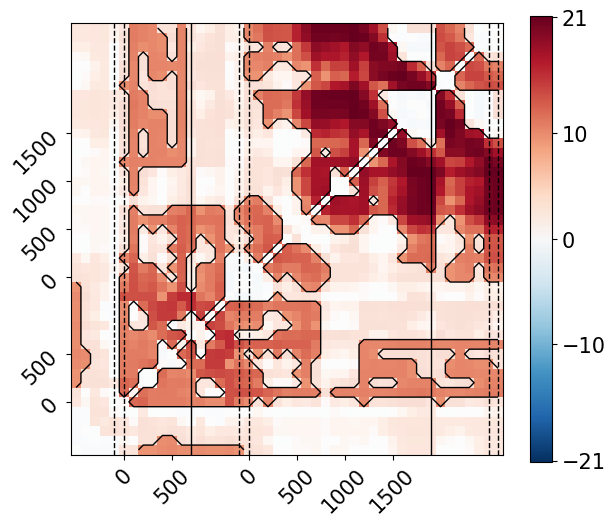

In [5]:
### inhibition vs control (pool features - pool loads)

filename = 'inhibition_vs_control'

output_i = 'inhibition_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'inhibition_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_inhibition = np.concatenate((procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, 
                                      procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, 
                                      procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, 
                                      procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_inhibition, axis=0))

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_inhibition
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True)


# inhibition - relevant vs control

stat_fun(H1): min=-8.333682351875554 max=12.476493084930468
Running initial clustering …
Using 63 thresholds from 0.00 to 12.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

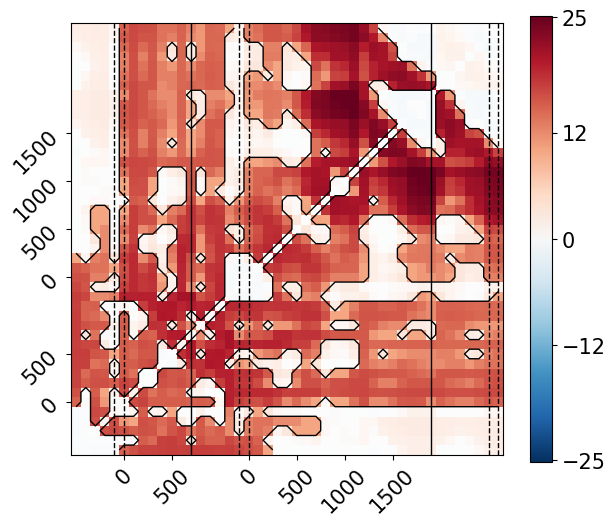

In [6]:
### inhibition - relevant vs control (pool features - pool loads)

filename = 'inhibition_relevant_vs_control'

output_i = 'inhibition_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'inhibition_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, 
                                      procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, 
                                      procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_relevant
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True)


# inhibition - non-relevant vs control

stat_fun(H1): min=-5.904341885801073 max=14.600632217022842
Running initial clustering …
Using 74 thresholds from 0.00 to 14.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

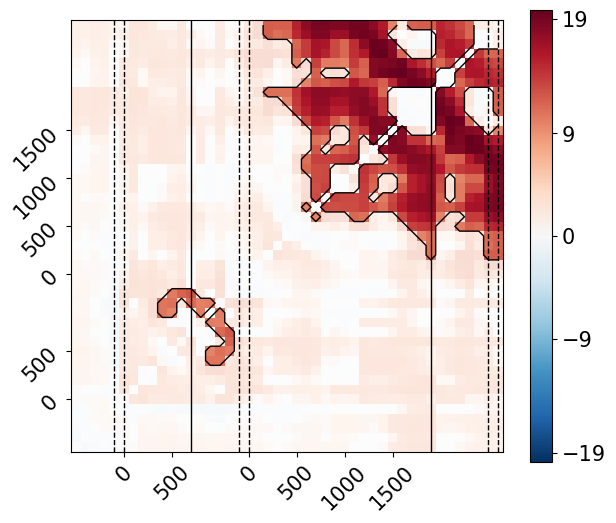

In [7]:
### inhibition non-relevant vs control (pool features - pool loads)

filename = 'inhibition_nonrelevant_vs_control'

output_i = 'inhibition_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'inhibition_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_nonrelevant = np.concatenate((procrustes_shape_nonrelevant_load1, 
                                      procrustes_shape_nonrelevant_load2, 
                                      procrustes_orientation_nonrelevant_load1, 
                                      procrustes_orientation_nonrelevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_nonrelevant, axis=0))

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_nonrelevant
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True)


# inhibition - relevant vs non-relevant


stat_fun(H1): min=-5.9244859233006135 max=6.015398067137744
Running initial clustering …
Using 31 thresholds from 0.00 to 6.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

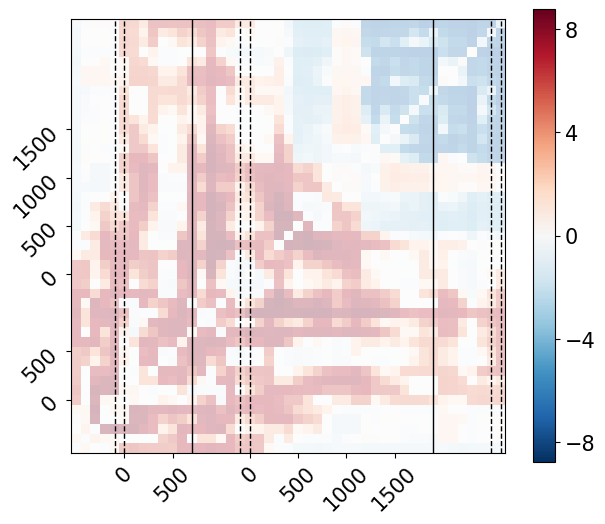

In [8]:
### inhibition - relevant vs non-relevant (pool features - pool loads)

filename = 'inhibition_relevant_vs_nonrelevant'

output_i = 'inhibition_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'inhibition_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))

procrustes_nonrelevant = np.concatenate((procrustes_orientation_nonrelevant_load1, procrustes_orientation_nonrelevant_load2, 
                                         procrustes_shape_nonrelevant_load1, procrustes_shape_nonrelevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_nonrelevant, axis=0))

group1 = procrustes_relevant
group2 = procrustes_nonrelevant

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True)



# update vs control

stat_fun(H1): min=-8.956439610444544 max=12.197112134184184
Running initial clustering …
Using 61 thresholds from 0.00 to 12.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

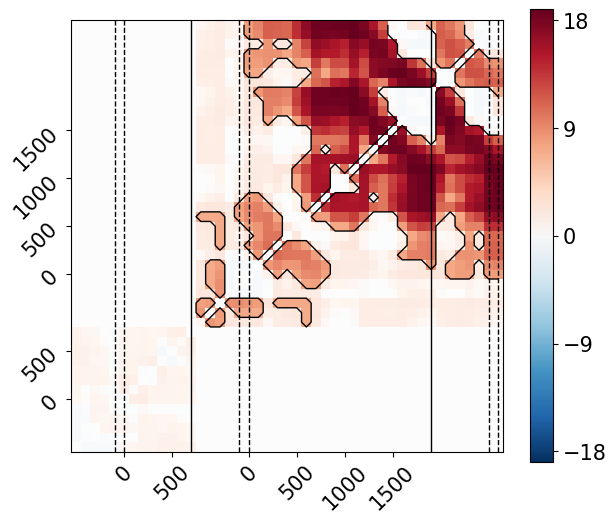

In [9]:
### update vs control (pool features - pool loads)

filename = 'update_vs_control'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_update = np.concatenate((procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, 
                                      procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, 
                                      procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, 
                                      procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2), axis=0)

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)

for i in range(procrustes_update.shape[0]):
    procrustes_update[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_update[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]

# plot_procrustes_heatmap(np.mean(procrustes_inhibition, axis=0))
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))


group1 = procrustes_inhibition
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# update - relevant vs control

stat_fun(H1): min=-8.124111914982482 max=11.923051155016275
Running initial clustering …
Using 60 thresholds from 0.00 to 11.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

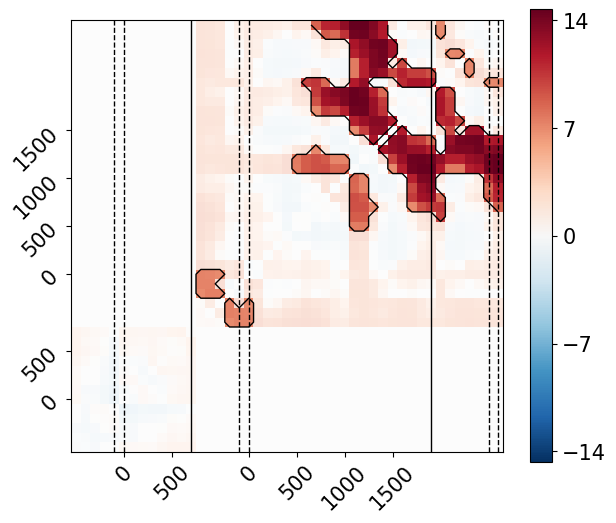

In [10]:
### update - relevant vs control (pool features - pool loads)

filename = 'update_relevant_vs_control'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_update = np.concatenate((procrustes_orientation_relevant_load1, 
                                      procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, 
                                      procrustes_shape_relevant_load2), axis=0)

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)

for i in range(procrustes_update.shape[0]):
    procrustes_update[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_update[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]

# plot_procrustes_heatmap(np.mean(procrustes_update, axis=0))
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_update
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# update - non-relevant vs control

stat_fun(H1): min=-9.821747410915837 max=10.094211191107805
Running initial clustering …
Using 51 thresholds from 0.00 to 10.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

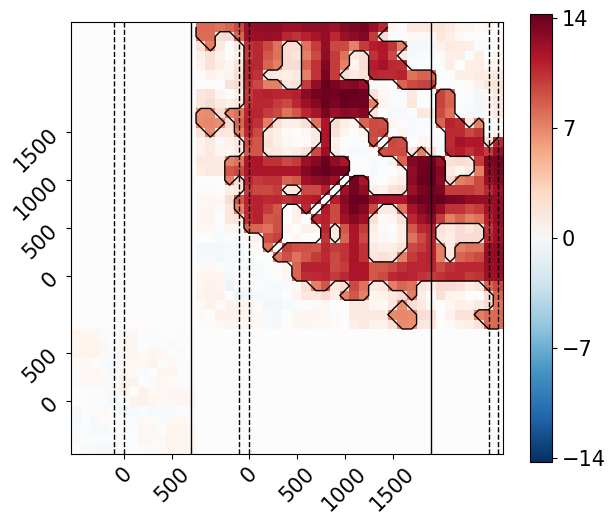

In [11]:
### update - non-relevant vs control (pool features - pool loads)

filename = 'update_nonrelevant_vs_control'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_update = np.concatenate((procrustes_orientation_nonrelevant_load1, 
                                      procrustes_orientation_nonrelevant_load2, 
                                      procrustes_shape_nonrelevant_load1, 
                                      procrustes_shape_nonrelevant_load2), axis=0)

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)

for i in range(procrustes_update.shape[0]):
    procrustes_update[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_update[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]

# plot_procrustes_heatmap(np.mean(procrustes_update, axis=0))
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_update
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# update - no-longer-relevant vs control

stat_fun(H1): min=-7.77656257697148 max=14.748696263326687
Running initial clustering …
Using 74 thresholds from 0.00 to 14.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

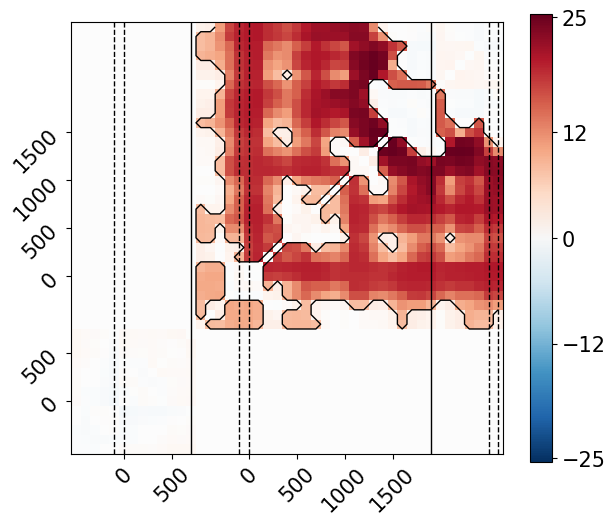

In [12]:
### update - no-longer-relevant vs control (pool features - pool loads)

filename = 'update_nolongerrelevant_vs_control'

output_i = 'update_1gratings_nolongerrelevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nolongerrelevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_nolongerrelevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_nolongerrelevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_update = np.concatenate((procrustes_orientation_relevant_load1, 
                                      procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, 
                                      procrustes_shape_relevant_load2), axis=0)

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)

for i in range(procrustes_update.shape[0]):
    procrustes_update[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_update[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]

# plot_procrustes_heatmap(np.mean(procrustes_update, axis=0))
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

group1 = procrustes_update
group2 = procrustes_control

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# update - relevant vs non-relevant


stat_fun(H1): min=-6.543006374680823 max=5.816027959982457
Running initial clustering …
Using 33 thresholds from 0.00 to 6.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

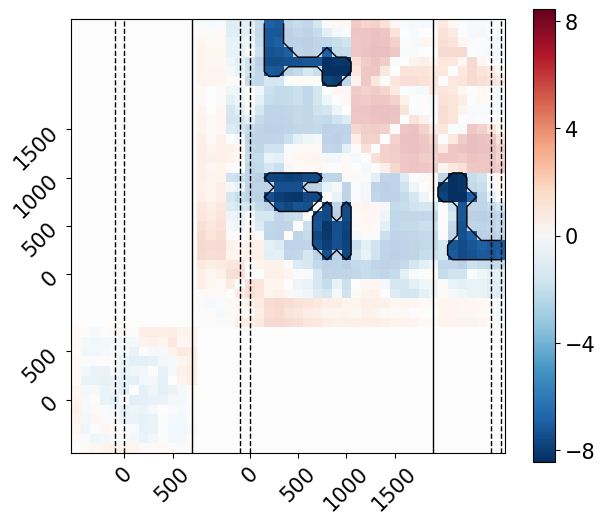

In [13]:
### update - relevant vs non-relevant (pool features - pool loads)

filename = 'update_relevant_vs_nonrelevant'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))

procrustes_nonrelevant = np.concatenate((procrustes_orientation_nonrelevant_load1, procrustes_orientation_nonrelevant_load2, 
                                         procrustes_shape_nonrelevant_load1, procrustes_shape_nonrelevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_nonrelevant, axis=0))

for i in range(procrustes_relevant.shape[0]):
    procrustes_relevant[i,13:,:13] = procrustes_nonrelevant[random.randint(0, procrustes_nonrelevant.shape[0]-1),13:,:13]
    procrustes_relevant[i,:13,13:] = procrustes_nonrelevant[random.randint(0, procrustes_nonrelevant.shape[0]-1),:13,13:]

group1 = procrustes_relevant
group2 = procrustes_nonrelevant

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# update - relevant vs no-longer-relevant


stat_fun(H1): min=-10.194482999644757 max=9.264495587670371
Running initial clustering …
Using 51 thresholds from 0.00 to 10.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

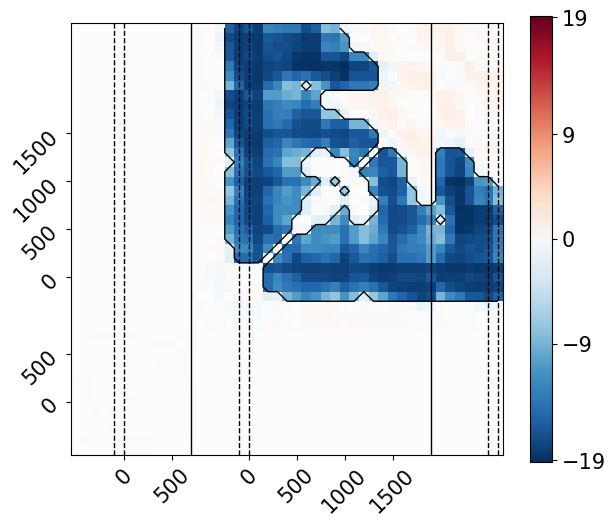

In [14]:
### update - relevant vs no-longer-relevant (pool features - pool loads)

filename = 'update_relevant_vs_nolongerrelevant'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, _, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, _, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
_, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
_, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)


output_i = 'update_1gratings_nolongerrelevant_1polygons_nonrelevant'
procrustes_orientation_nolongerrelevant_load1, _, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nolongerrelevant_2polygons_nonrelevant'
procrustes_orientation_nolongerrelevant_load2, _, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_1gratings_nonrelevant_1polygons_nolongerrelevant'
_, procrustes_shape_nolongerrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_nolongerrelevant'
_, procrustes_shape_nolongerrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, procrustes_shape_relevant_load2), axis=0)

procrustes_nolongerrelevant = np.concatenate((procrustes_orientation_nolongerrelevant_load1, procrustes_orientation_nolongerrelevant_load2, 
                                         procrustes_shape_nolongerrelevant_load1, procrustes_shape_nolongerrelevant_load2), axis=0)

output_i = 'control_2gratings_2polygons'
procrustes_orientation_load2, procrustes_shape_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'control_1gratings_1polygons'
procrustes_orientation_load1, procrustes_shape_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_control = np.concatenate((procrustes_orientation_load1, procrustes_orientation_load2, 
                                         procrustes_shape_load1, procrustes_shape_load2), axis=0)

for i in range(procrustes_relevant.shape[0]):
    procrustes_relevant[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_relevant[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]
    procrustes_relevant[i,:13,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,:13]

for i in range(procrustes_nolongerrelevant.shape[0]):
    procrustes_nolongerrelevant[i,13:,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),13:,:13]
    procrustes_nolongerrelevant[i,:13,13:] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,13:]
    procrustes_nolongerrelevant[i,:13,:13] = procrustes_control[random.randint(0, procrustes_control.shape[0]-1),:13,:13]

# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))
# plot_procrustes_heatmap(np.mean(procrustes_nolongerrelevant, axis=0))

group1 = procrustes_relevant
group2 = procrustes_nolongerrelevant

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# inhibition vs update


stat_fun(H1): min=-10.128835564077416 max=15.88240795241178
Running initial clustering …
Using 80 thresholds from 0.00 to 15.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

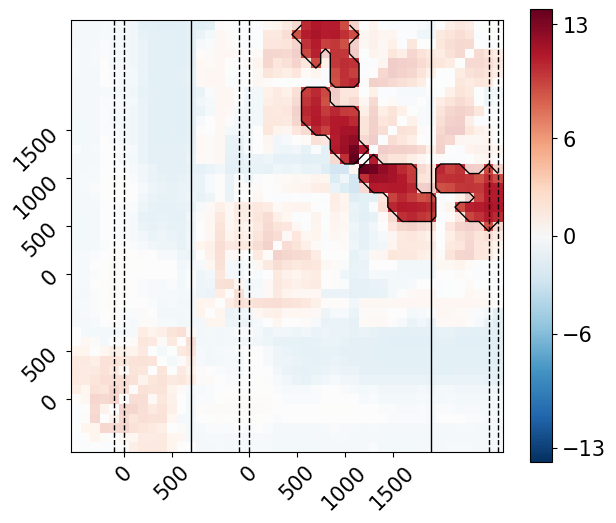

In [15]:
### inhibition vs update (pool features - pool loads)

filename = 'inhibition_vs_update'

output_i = 'inhibition_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'inhibition_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'inhibition_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_inhibition = np.concatenate((procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, 
                                      procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, 
                                      procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, 
                                      procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_inhibition, axis=0))

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_update = np.concatenate((procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, 
                                      procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, 
                                      procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, 
                                      procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_control, axis=0))

for i in range(procrustes_update.shape[0]):
    procrustes_update[i,13:,:13] = procrustes_inhibition[random.randint(0, procrustes_inhibition.shape[0]-1),13:,:13]
    procrustes_update[i,:13,13:] = procrustes_inhibition[random.randint(0, procrustes_inhibition.shape[0]-1),:13,13:]

group1 = procrustes_inhibition
group2 = procrustes_update


path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True)


# inhibition-relevant vs update-relevant

stat_fun(H1): min=-6.543006374680823 max=6.985624329868202
Running initial clustering …
Using 35 thresholds from 0.00 to 6.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

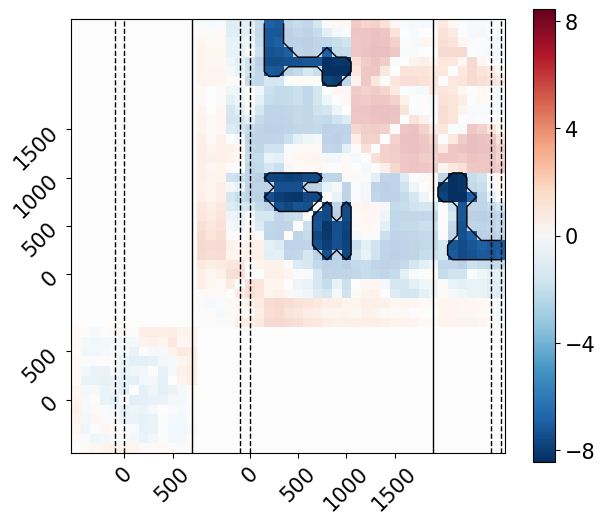

In [16]:
### inhibition-relevant vs update-relevant

filename = 'relevant_inhibition_vs_update'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))

procrustes_nonrelevant = np.concatenate((procrustes_orientation_nonrelevant_load1, procrustes_orientation_nonrelevant_load2, 
                                         procrustes_shape_nonrelevant_load1, procrustes_shape_nonrelevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_nonrelevant, axis=0))

group1 = procrustes_relevant
group2 = procrustes_nonrelevant

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)


# inhibition-nonrelevant vs update-nonrelevant

stat_fun(H1): min=-6.543006374680823 max=6.985624329868202
Running initial clustering …
Using 35 thresholds from 0.00 to 6.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 2025 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

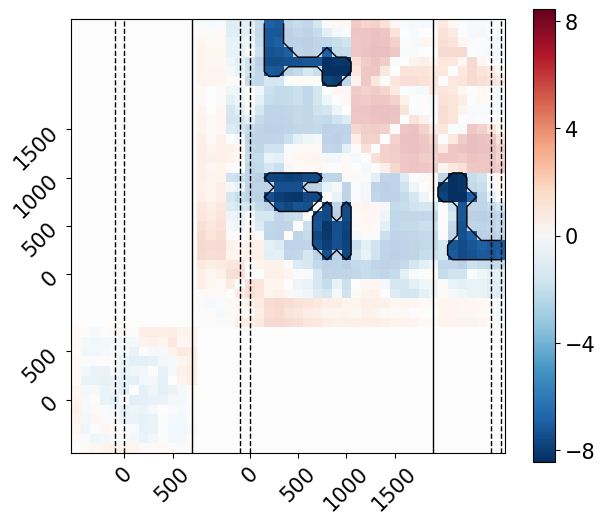

In [17]:
### inhibition-nonrelevant vs update-nonrelevant

filename = 'nonrelevant_inhibition_vs_update'

output_i = 'update_1gratings_relevant_1polygons_nonrelevant'
procrustes_orientation_relevant_load1, procrustes_shape_nonrelevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_relevant_2polygons_nonrelevant'
procrustes_orientation_relevant_load2, procrustes_shape_nonrelevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

output_i = 'update_1gratings_nonrelevant_1polygons_relevant'
procrustes_orientation_nonrelevant_load1, procrustes_shape_relevant_load1, _ = pool_procrustes_distances(output_i, subjects, path_inputs)
output_i = 'update_2gratings_nonrelevant_2polygons_relevant'
procrustes_orientation_nonrelevant_load2, procrustes_shape_relevant_load2, _ = pool_procrustes_distances(output_i, subjects, path_inputs)

procrustes_relevant = np.concatenate((procrustes_orientation_relevant_load1, procrustes_orientation_relevant_load2, 
                                      procrustes_shape_relevant_load1, procrustes_shape_relevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_relevant, axis=0))

procrustes_nonrelevant = np.concatenate((procrustes_orientation_nonrelevant_load1, procrustes_orientation_nonrelevant_load2, 
                                         procrustes_shape_nonrelevant_load1, procrustes_shape_nonrelevant_load2), axis=0)
# plot_procrustes_heatmap(np.mean(procrustes_nonrelevant, axis=0))

group1 = procrustes_relevant
group2 = procrustes_nonrelevant

path_figure = os.path.join(path_folder_figure, filename + '.png')
T_obs, clusters, cluster_p_values = cluster_permutation_symmetric_matrix(group1, group2, threshold=threshold, path_figure=path_figure, p_thr=0.025, symmetric_bar=True, update=True)
